In [15]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [16]:
pred_500 = pd.read_csv("/scratch/st-cdeboer-1/sambina/mpra_position_paper/figure_2/yeast_motifs/output/predicted_all_yeast_full_knockout.csv")
pred_500_rc = pd.read_csv("/scratch/st-cdeboer-1/sambina/mpra_position_paper/figure_2/yeast_motifs/output/predicted_all_yeast_full_knockout_rc.csv")


In [17]:
print(pred_500.columns)


Index(['Unnamed: 0.1', 'Unnamed: 0', 'seq_id', 'motif_name', 'seq_200',
       'start_pos', 'offset', 'seq_-30', 'seq_-29', 'seq_-28',
       ...
       'pred_seq_21', 'pred_seq_22', 'pred_seq_23', 'pred_seq_24',
       'pred_seq_25', 'pred_seq_26', 'pred_seq_27', 'pred_seq_28',
       'pred_seq_29', 'pred_seq_30'],
      dtype='object', length=129)


In [20]:
# pred_500[['motif_group', 'motif_type']] = pred_500['motif_name'].str.extract(r'^([^_]+)_([^_]+)')

split_cols = pred_500['motif_name'].str.split('_', n=1, expand=True)
pred_500['motif_group'] = split_cols[0]
pred_500['motif_type'] = split_cols[1]

pred_500_ref = pred_500[pred_500['motif_type'] != 'mut'].copy()
pred_500_alt = pred_500[pred_500['motif_type'] == 'mut'].copy()

pred_500_ref.drop(columns=['motif_type'], inplace=True)
pred_500_alt.drop(columns=['motif_type'], inplace=True)

pred_500_ref = pred_500_ref.rename(columns={col: f"ref_{col}" for col in pred_500_ref.columns if col not in ['seq_id', 'motif_group', 'motif_name']})
pred_500_alt = pred_500_alt.rename(columns={col: f"alt_{col}" for col in pred_500_alt.columns if col not in ['seq_id', 'motif_group', 'motif_name']})

merged_df = pd.merge(pred_500_ref, pred_500_alt, on=['seq_id', 'motif_group'], how='inner')

offsets = list(range(-30, 31, 1))

# Compute diff_offset for each offset
for offset in offsets:
    merged_df[f'diff_{offset}'] =  merged_df[f'ref_pred_seq_{offset}'] - merged_df[f'alt_pred_seq_{offset}']

avg_diff = merged_df.groupby('motif_group')[[f'diff_{offset}' for offset in offsets]].mean().reset_index()


AttributeError: module 'numpy' has no attribute 'matrix'

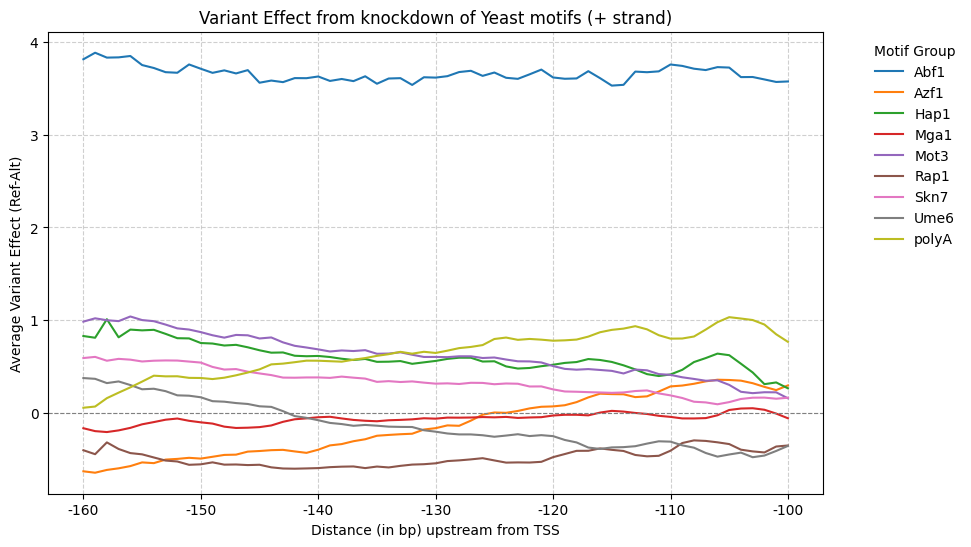

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set x-axis values (offsets)
offsets = list(range(-30, 31, 1))  # Original offset values

# Map offsets to new range (-160 to -100) using linear scaling
mapped_offsets = np.linspace(-100, -160, len(offsets)) # Linearly map offsets to -160 to -100
# mapped_offsets = offsets
# Select only every 10th tick for display
xticks_positions = mapped_offsets[::10]  # Every 10th position
xticks_labels = [str(int(x)) for x in xticks_positions]  # Convert to integer labels

# Plot each motif_group's diff_offset values
plt.figure(figsize=(10, 6))

for _, row in avg_diff.iterrows():
    plt.plot(mapped_offsets, row[1:], label=row['motif_group'])  # Use mapped offsets

# Formatting
plt.xlabel("Distance (in bp) upstream from TSS")
plt.ylabel("Average Variant Effect (Ref-Alt)")
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0
plt.xticks(xticks_positions, xticks_labels)  # Apply filtered labels
plt.legend(title="Motif Group", bbox_to_anchor=(1.05, 1), loc="upper left",  frameon=False)
plt.grid(True, linestyle="--", alpha=0.6)
plt.title("Variant Effect from knockdown of Yeast motifs (+ strand)")
plt.savefig("/scratch/st-cdeboer-1/sambina/mpra_position_paper/figure_2/yeast_motifs/output/yeast_full_knockout.svg",format="svg")

# plt.ylim(-1, 1.05)
# Show plot
plt.show()


### Plot RC

In [ ]:
pred_500_rc['motif_group'] = pred_500_rc['motif_name'].str.split('_').str[0]
pred_500_rc['motif_type'] = pred_500_rc['motif_name'].str.split('_').str[1]

pred_500_rc_ref = pred_500_rc[pred_500_rc['motif_type'] != 'mut'].copy()
pred_500_rc_alt = pred_500_rc[pred_500_rc['motif_type'] == 'mut'].copy()

pred_500_rc_ref.drop(columns=['motif_type'], inplace=True)
pred_500_rc_alt.drop(columns=['motif_type'], inplace=True)

pred_500_rc_ref = pred_500_rc_ref.rename(columns={col: f"ref_{col}" for col in pred_500_rc_ref.columns if col not in ['seq_id', 'motif_group', 'motif_name']})
pred_500_rc_alt = pred_500_rc_alt.rename(columns={col: f"alt_{col}" for col in pred_500_rc_alt.columns if col not in ['seq_id', 'motif_group', 'motif_name']})

merged_df_rc = pd.merge(pred_500_rc_ref, pred_500_rc_alt, on=['seq_id', 'motif_group'], how='inner')

offsets = list(range(-30, 31, 1))
# Compute diff_offset for each offset
for offset in offsets:
    merged_df_rc[f'diff_{offset}'] = merged_df_rc[f'ref_pred_seq_{offset}'] - merged_df_rc[f'alt_pred_seq_{offset}']

avg_diff_rc = merged_df_rc.groupby('motif_group')[[f'diff_{offset}' for offset in offsets]].mean().reset_index()

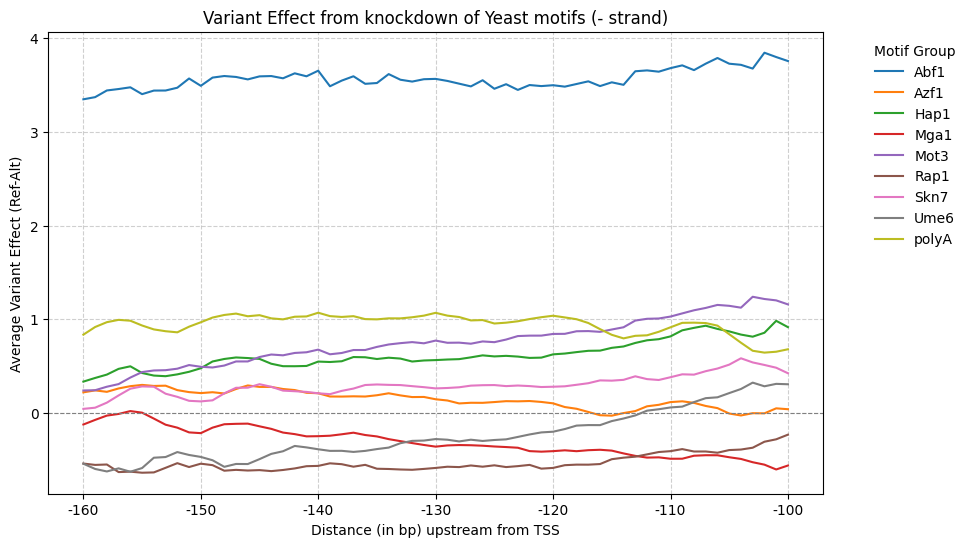

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set x-axis values (offsets)
offsets = list(range(-30, 31, 1))  # Original offset values

# Map offsets to new range (-160 to -100) using linear scaling
mapped_offsets = np.linspace(-100, -160, len(offsets)) # Linearly map offsets to -160 to -100
# mapped_offsets = offsets
# Select only every 10th tick for display
xticks_positions = mapped_offsets[::10]  # Every 10th position
xticks_labels = [str(int(x)) for x in xticks_positions]  # Convert to integer labels

# Plot each motif_group's diff_offset values
plt.figure(figsize=(10, 6))

for _, row in avg_diff_rc.iterrows():
    plt.plot(mapped_offsets, row[1:], label=row['motif_group'])  # Use mapped offsets

# Formatting
# plt.xlabel("Distance (in bp) upstream from TSS")
# plt.ylabel("Average Variant Effect (Ref-Alt)")
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0
# plt.xticks(xticks_positions, xticks_labels) 


plt.xlabel("Distance (in bp) upstream from TSS", fontsize=14)
plt.ylabel("Average Variant Effect (Ref-Alt)", fontsize=14)
plt.xticks(xticks_positions, xticks_labels, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Motif Group", bbox_to_anchor=(1.05, 1), loc="upper left",  frameon=False)
plt.grid(True, linestyle="--", alpha=0.6)
plt.title("Variant Effect from knockdown of Yeast motifs (- strand)")
plt.savefig("/scratch/st-cdeboer-1/sambina/mpra_position_paper/figure_2/yeast_motifs/output/yeast_full_knockout_rc.svg",format="svg")


# Show plot
plt.show()